# Automotive Part Image-Text Matching

**Focused Deep Learning exam notebook — Step 011.5**

### The one question

> **Does a multimodal neural network that combines an automotive-part image and a short description classify their relationship better than image-only and text-only neural baselines?**

This notebook is intentionally narrower than the full repository. It shows one
experiment, the evidence needed to judge it, concrete examples, concrete
failures, and a reproducible boundary. The wider course exercises and audit
material remain available as supporting evidence.

## 1. One research question

The input is a photograph of an automotive part and a short description. The
output is one of three relationships:

- `MATCH`: the same part category;
- `PARTIAL_MATCH`: a different category from the same automotive system;
- `MISMATCH`: a category from a different automotive system.

The central comparison is multimodal versus text-only and image-only models on
the same group-isolated validation set.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

ROOT = Path.cwd()
if not (ROOT / "reports").is_dir():
    ROOT = ROOT.parent

train = pd.read_csv(ROOT / "data/processed/integrated_train.csv")
validation = pd.read_csv(ROOT / "data/processed/integrated_validation.csv")
comparison = pd.read_csv(
    ROOT / "reports/integrated_training/validation_comparison.csv"
)
errors = pd.read_csv(
    ROOT / "reports/validation_model_improvement/validation_error_analysis.csv"
)
with (
    ROOT
    / "reports/validation_model_improvement/validation_error_analysis.json"
).open(encoding="utf-8") as handle:
    error_summary = json.load(handle)

print("Evidence loaded from committed train/validation reports only.")
print("No model training is performed in this notebook.")

Evidence loaded from committed train/validation reports only.
No model training is performed in this notebook.


## 2. Data and labels

The final comparison uses generated development images together with manually
reviewed open-license photographs. Each physical part appears in three
image-text relationships, but all relationships for that physical part remain
in the same split.

In [2]:
dataset_summary = pd.DataFrame(
    {
        "split": ["train", "validation"],
        "samples": [len(train), len(validation)],
        "physical_part_groups": [
            train["part_group_id"].nunique(),
            validation["part_group_id"].nunique(),
        ],
        "images": [train["image_id"].nunique(), validation["image_id"].nunique()],
    }
)
display(dataset_summary)

display(
    validation.groupby(["source", "label"])
    .size()
    .rename("samples")
    .reset_index()
)

,split,samples,physical_part_groups,images
0,train,180,60,60
1,validation,60,20,20


,source,label,samples
0,generated_development,MATCH,10
1,generated_development,MISMATCH,10
2,generated_development,PARTIAL_MATCH,10
3,wikimedia_commons_open_license,MATCH,10
4,wikimedia_commons_open_license,MISMATCH,10
5,wikimedia_commons_open_license,PARTIAL_MATCH,10


## 3. Leakage protection

A row-level random split would be invalid here. The same physical part could
appear with different descriptions on both sides of the split, letting the
model benefit from object identity rather than learn the intended relationship.
The split therefore uses `part_group_id`.

In [3]:
overlap = pd.DataFrame(
    {
        "check": [
            "part_group_id overlap",
            "image_id overlap",
            "image_path overlap",
        ],
        "count": [
            len(set(train["part_group_id"]) & set(validation["part_group_id"])),
            len(set(train["image_id"]) & set(validation["image_id"])),
            len(set(train["image_path"]) & set(validation["image_path"])),
        ],
    }
)
display(overlap)
assert overlap["count"].eq(0).all()
print("Group, image ID, and image path isolation: PASS")

,check,count
0,part_group_id overlap,0
1,image_id overlap,0
2,image_path overlap,0


Group, image ID, and image path isolation: PASS


## 4. Models compared

The same validation split is used for six models: a majority baseline,
classical text and image baselines, neural text-only and image-only models, and
the retained multimodal network. The main metric is macro F1 because all three
classes matter.

,validation_rank,model,input_modality,integrated_validation_accuracy,integrated_validation_macro_f1
0,1,Keras Multimodal Neural Network,image_and_text,0.533333,0.520827
1,2,TF-IDF + Logistic Regression,text,0.416667,0.329966
2,3,Keras Text Neural Network,text,0.416667,0.329966
3,4,Majority baseline,none,0.333333,0.166667
4,5,Image pixels + Logistic Regression,image,0.333333,0.166667
5,6,Keras Image Neural Network,image,0.333333,0.166667


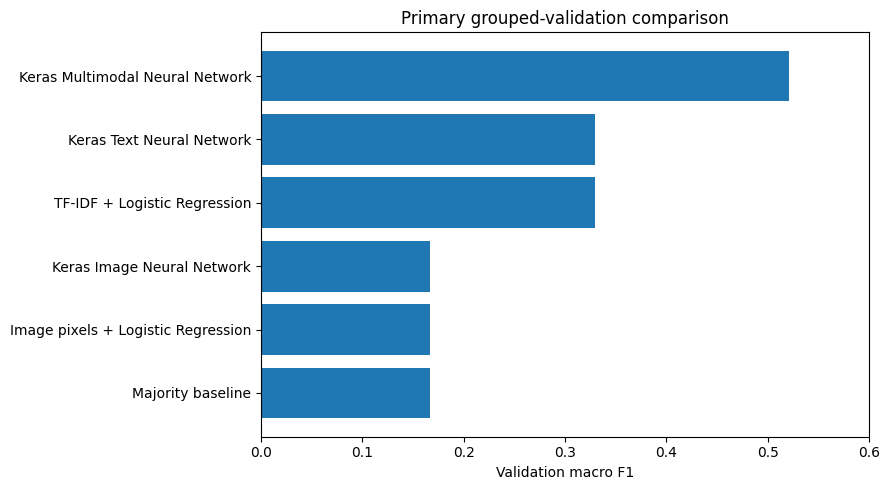

In [4]:
result_columns = [
    "validation_rank",
    "model",
    "input_modality",
    "integrated_validation_accuracy",
    "integrated_validation_macro_f1",
]
results = comparison[result_columns].sort_values("validation_rank")
display(results)

plot_data = results.sort_values(
    "integrated_validation_macro_f1", ascending=True
)
figure, axis = plt.subplots(figsize=(9, 5))
axis.barh(plot_data["model"], plot_data["integrated_validation_macro_f1"])
axis.set_xlabel("Validation macro F1")
axis.set_xlim(0.0, 0.6)
axis.set_title("Primary grouped-validation comparison")
figure.tight_layout()
plt.show()

## 5. Main validation result

The multimodal model ranks first with `0.5333` accuracy and `0.5208` macro F1.
This is better than both neural unimodal baselines, but the score is modest and
must be read together with the error analysis. A higher result on the earlier
generated-only development set is not used as the final claim.

## 6. What the multimodal model adds

Aggregate metrics alone do not show whether combining image and text helps on
specific cases. The next comparison joins the predictions and surfaces cases
where the multimodal model is correct while one or both unimodal models fail.

,sample_id,source,description,true_label,multimodal_prediction,text_prediction,image_prediction
1,air_filter_004_01_mismatch,generated_development,Automotive starter motor.,MISMATCH,MISMATCH,MISMATCH,MATCH
4,alternator_004_01_mismatch,generated_development,Automotive brake disc.,MISMATCH,MISMATCH,MISMATCH,MATCH
7,brake_disc_004_01_mismatch,generated_development,Automotive shock absorber.,MISMATCH,MISMATCH,MISMATCH,MATCH
8,brake_disc_004_01_partial_match,generated_development,Automotive brake pad set.,PARTIAL_MATCH,PARTIAL_MATCH,MATCH,MATCH
10,brake_pad_004_01_mismatch,generated_development,Automotive shock absorber.,MISMATCH,MISMATCH,MISMATCH,MATCH
13,coil_spring_004_01_mismatch,generated_development,Automotive headlight assembly.,MISMATCH,MISMATCH,MISMATCH,MATCH
17,external_sample_air_filter_475881_partial_match,wikimedia_commons_open_license,Automotive engine oil filter.,PARTIAL_MATCH,PARTIAL_MATCH,MISMATCH,MATCH
20,external_sample_alternator_12811841_partial_match,wikimedia_commons_open_license,Automotive starter motor.,PARTIAL_MATCH,PARTIAL_MATCH,MISMATCH,MATCH


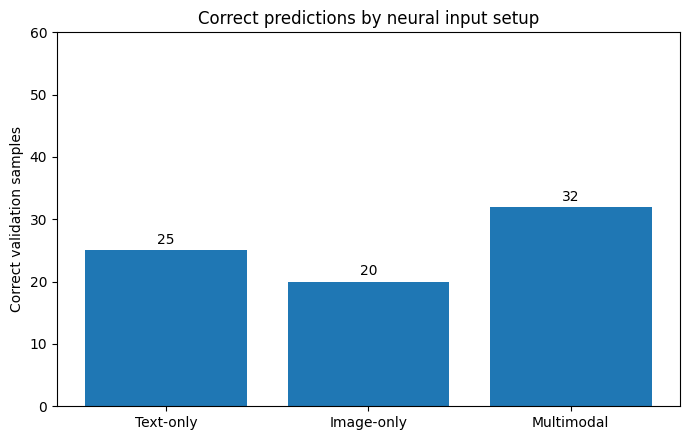

In [5]:
def load_predictions(slug, prefix):
    frame = pd.read_csv(
        ROOT / f"reports/integrated_training/{slug}/validation_predictions.csv"
    )
    return frame[["sample_id", "predicted_label", "is_correct"]].rename(
        columns={
            "predicted_label": f"{prefix}_prediction",
            "is_correct": f"{prefix}_correct",
        }
    )

multimodal = pd.read_csv(
    ROOT
    / "reports/integrated_training/keras_multimodal/validation_predictions.csv"
)
joined = (
    multimodal.rename(
        columns={
            "predicted_label": "multimodal_prediction",
            "is_correct": "multimodal_correct",
        }
    )
    .merge(load_predictions("keras_text", "text"), on="sample_id")
    .merge(load_predictions("keras_image", "image"), on="sample_id")
)

multimodal_wins = joined[
    joined["multimodal_correct"]
    & (~joined["text_correct"] | ~joined["image_correct"])
].copy()
columns = [
    "sample_id",
    "source",
    "description",
    "true_label",
    "multimodal_prediction",
    "text_prediction",
    "image_prediction",
]
display(multimodal_wins[columns].head(8))

counts = pd.DataFrame(
    {
        "model": ["Text-only", "Image-only", "Multimodal"],
        "correct": [
            int(joined["text_correct"].sum()),
            int(joined["image_correct"].sum()),
            int(joined["multimodal_correct"].sum()),
        ],
    }
)
figure, axis = plt.subplots(figsize=(7, 4.5))
axis.bar(counts["model"], counts["correct"])
axis.set_ylim(0, 60)
axis.set_ylabel("Correct validation samples")
axis.set_title("Correct predictions by neural input setup")
for index, value in enumerate(counts["correct"]):
    axis.text(index, value + 1, str(value), ha="center")
figure.tight_layout()
plt.show()

The examples support a limited claim: the two-modality model
resolves cases that one-modality models miss. They do not prove that every
prediction uses both inputs correctly, so the conclusion remains comparative
rather than causal.

## 7. Where the model fails

The retained model makes 35 errors among 60 validation samples. The main
failure is the intermediate `PARTIAL_MATCH` relationship. In the retained
confusion matrix, only one validation sample is predicted as `PARTIAL_MATCH`,
and none of the true partial matches are recovered as that class; they are
divided between `MATCH` and `MISMATCH`.

,predicted_MATCH,predicted_PARTIAL_MATCH,predicted_MISMATCH
actual_MATCH,10,0,10
actual_PARTIAL_MATCH,10,0,10
actual_MISMATCH,4,1,15


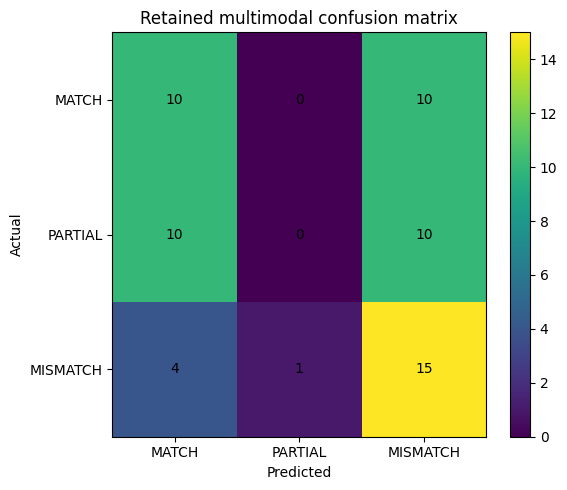

,error_pair,errors
0,MATCH->MISMATCH,10
1,PARTIAL_MATCH->MISMATCH,10
2,PARTIAL_MATCH->MATCH,10
3,MISMATCH->MATCH,4
4,MISMATCH->PARTIAL_MATCH,1


In [6]:
confusion = pd.read_csv(
    ROOT
    / "reports/validation_model_improvement/candidates/"
    "reference_multimodal/validation_confusion_matrix.csv",
    index_col=0,
)
display(confusion)

figure, axis = plt.subplots(figsize=(6, 5))
image = axis.imshow(confusion.to_numpy(), aspect="auto")
axis.set_xticks(range(3), ["MATCH", "PARTIAL", "MISMATCH"])
axis.set_yticks(range(3), ["MATCH", "PARTIAL", "MISMATCH"])
axis.set_xlabel("Predicted")
axis.set_ylabel("Actual")
axis.set_title("Retained multimodal confusion matrix")
for row in range(3):
    for column in range(3):
        axis.text(
            column,
            row,
            int(confusion.iloc[row, column]),
            ha="center",
            va="center",
        )
figure.colorbar(image, ax=axis)
figure.tight_layout()
plt.show()

display(
    errors.groupby("error_pair")
    .size()
    .rename("errors")
    .sort_values(ascending=False)
    .reset_index()
)

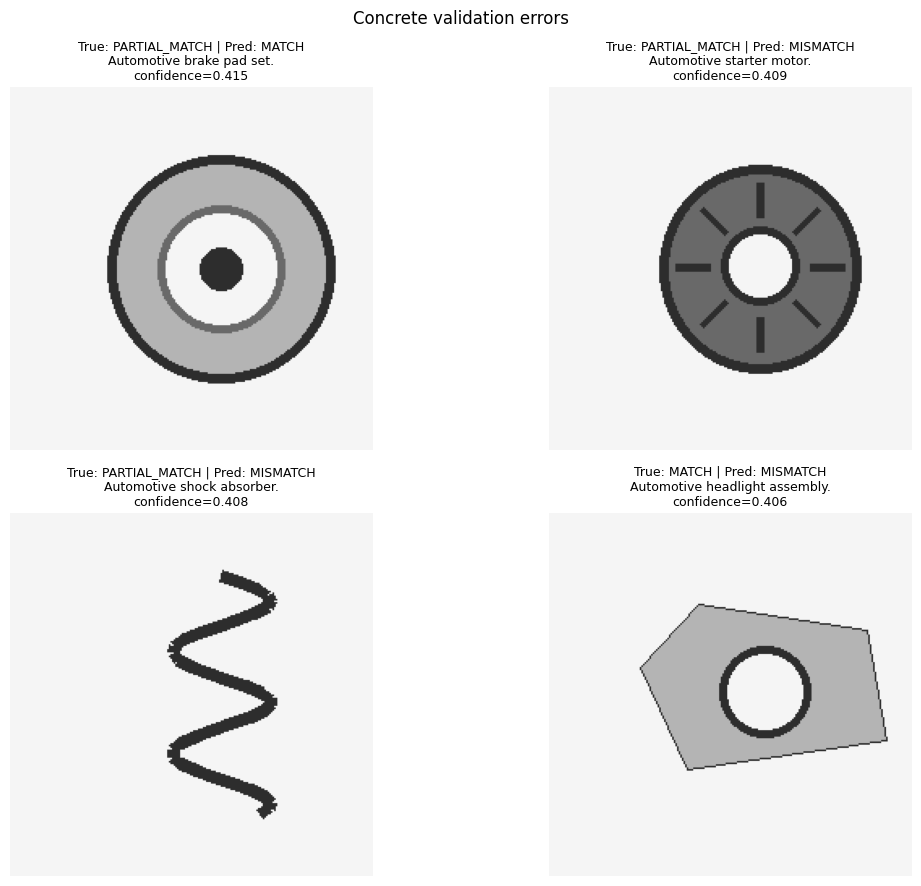

,sample_id,source,true_label,predicted_label,confidence,description
0,brake_disc_004_01_partial_match,generated_development,PARTIAL_MATCH,MATCH,0.414643,Automotive brake pad set.
1,alternator_004_01_partial_match,generated_development,PARTIAL_MATCH,MISMATCH,0.408629,Automotive starter motor.
2,coil_spring_004_01_partial_match,generated_development,PARTIAL_MATCH,MISMATCH,0.407800,Automotive shock absorber.
3,headlight_004_01_match,generated_development,MATCH,MISMATCH,0.405982,Automotive headlight assembly.


In [7]:
validation_images = validation[
    ["image_id", "image_path"]
].drop_duplicates("image_id")
example_errors = (
    errors.merge(validation_images, on="image_id", how="left")
    .sort_values("confidence", ascending=False)
    .head(4)
)

figure, axes = plt.subplots(2, 2, figsize=(12, 9))
for axis, (_, row) in zip(axes.flat, example_errors.iterrows()):
    image = Image.open(ROOT / row["image_path"]).convert("RGB")
    axis.imshow(image)
    axis.axis("off")
    axis.set_title(
        f"True: {row['true_label']} | Pred: {row['predicted_label']}\n"
        f"{row['description']}\nconfidence={row['confidence']:.3f}",
        fontsize=9,
    )
figure.suptitle("Concrete validation errors")
figure.tight_layout()
plt.show()

display(
    example_errors[
        [
            "sample_id",
            "source",
            "true_label",
            "predicted_label",
            "confidence",
            "description",
        ]
    ]
)

,source,errors,samples,error_rate
0,generated_development,15,30,0.500000
1,wikimedia_commons_open_license,20,30,0.666667


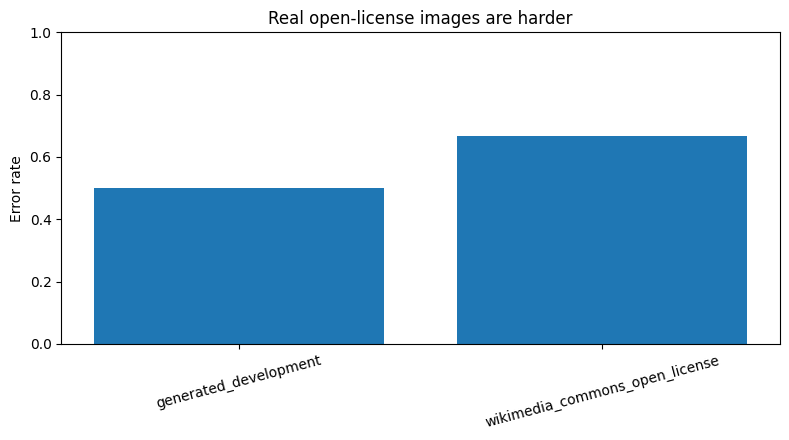

In [8]:
source_errors = (
    errors.groupby("source").size().rename("errors").reset_index()
)
source_totals = (
    validation.groupby("source").size().rename("samples").reset_index()
)
source_rates = source_errors.merge(source_totals, on="source")
source_rates["error_rate"] = (
    source_rates["errors"] / source_rates["samples"]
)
display(source_rates)

figure, axis = plt.subplots(figsize=(8, 4.5))
axis.bar(source_rates["source"], source_rates["error_rate"])
axis.set_ylim(0.0, 1.0)
axis.set_ylabel("Error rate")
axis.set_title("Real open-license images are harder")
axis.tick_params(axis="x", rotation=15)
figure.tight_layout()
plt.show()

## 8. Limits of the conclusion

The evidence supports the statement that the retained multimodal model is the
strongest of the compared models on this grouped validation split. It does not
support claims of production readiness, general performance across all vehicle
parts, calibrated probabilities, human-level explanation, or final test
performance.

The small dataset, the failure to predict `PARTIAL_MATCH`, and the higher error
rate on real images are the main limitations.

## 9. Reproduction and evaluation boundary

From the repository root:

```powershell
python -m src.project_cli build-exam-first-submission
python -m src.project_cli verify-exam-first-submission
```

The exam-facing build reads committed train and validation evidence. It does
not train a model, open locked test CSV files, authorize final test evaluation,
or change the retained production model.

In [9]:
freeze_path = (
    ROOT / "reports/final_model_freeze/final_model_freeze_status.json"
)
with freeze_path.open(encoding="utf-8") as handle:
    freeze_status = json.load(handle)

boundary = pd.DataFrame(
    [
        {
            "model_training_performed": False,
            "locked_test_csv_files_opened": False,
            "test_split_used": False,
            "final_test_evaluation_authorized": False,
            "production_final_model_changed": False,
            "retained_model": freeze_status["final_model_slug"],
            "selection_decision": freeze_status["selection_decision"],
        }
    ]
)
display(boundary)
assert freeze_status["protocol_frozen"] is True
assert freeze_status["test_lock_preserved"] is True
print("Evaluation boundary: PASS")

,model_training_performed,locked_test_csv_files_opened,test_split_used,final_test_evaluation_authorized,production_final_model_changed,retained_model,selection_decision
0,False,False,False,False,False,keras_multimodal,REFERENCE_RETAINED


Evaluation boundary: PASS


## 10. Conclusion

The multimodal network is the best model in the controlled comparison because
the task depends on both the photographed part and the description. Its
advantage over the unimodal neural baselines is visible both in macro F1 and in
specific examples. The model is still weak on `PARTIAL_MATCH` and on real
images, so the correct conclusion is improvement, not completion.

The next scientific step should improve the data and the handling of the
intermediate relationship before any final test evaluation is authorized.

## References

1. Faghri, F. et al. *VSE++: Improving Visual-Semantic Embeddings with Hard Negatives.* BMVC, 2018.
2. Li, L. H. et al. *VisualBERT: A Simple and Performant Baseline for Vision and Language.* 2019.
3. Radford, A. et al. *Learning Transferable Visual Models From Natural Language Supervision.* ICML, 2021.
4. Vaswani, A. et al. *Attention Is All You Need.* NeurIPS, 2017.
5. He, K. et al. *Deep Residual Learning for Image Recognition.* CVPR, 2016.
6. scikit-learn documentation: model evaluation and grouped cross-validation.